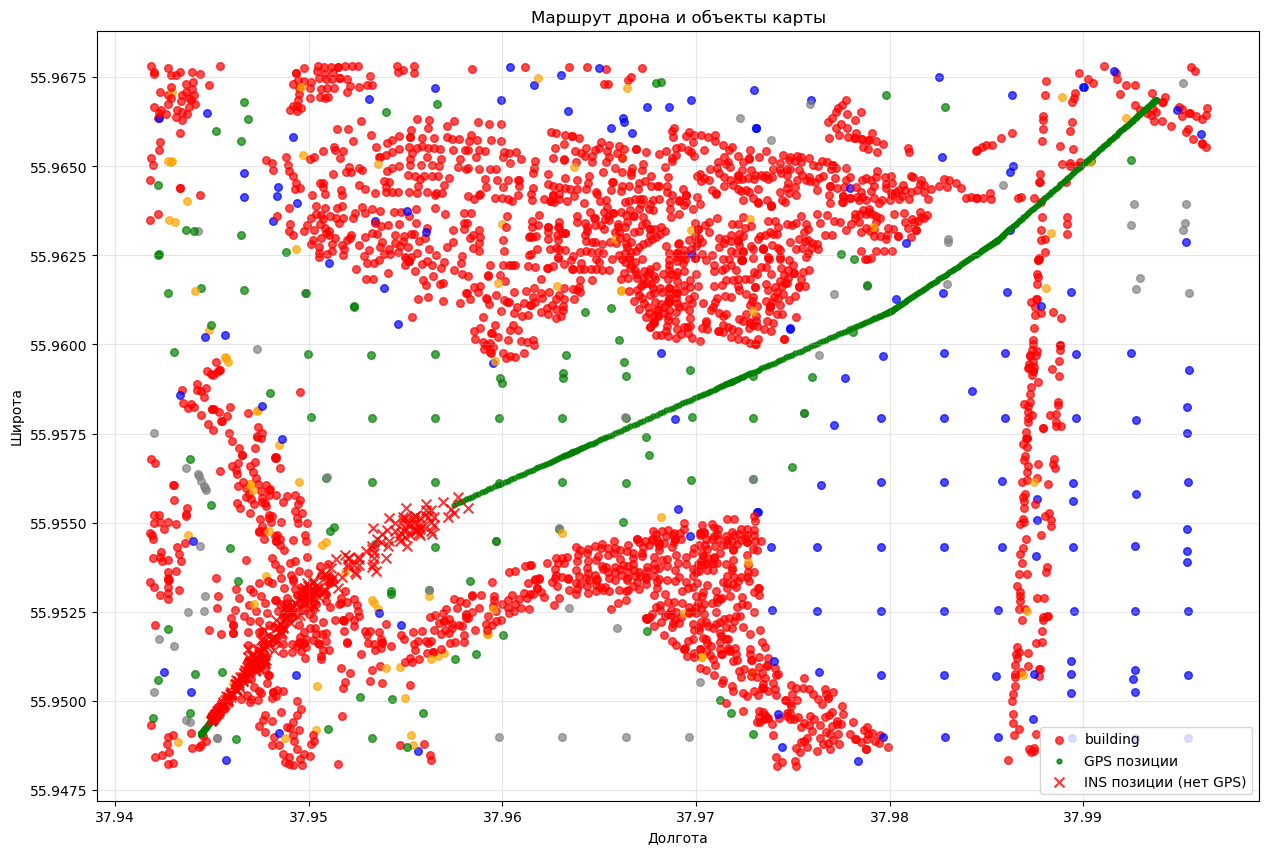

Всего точек маршрута: 900
GPS точек: 601
INS точек: 299
Объектов на карте: 2850


In [9]:
 
import json
import matplotlib.pyplot as plt

# Загрузка данных
with open('flight_data_visible_error.json', 'r') as f:
    flight_data = json.load(f)

with open('json_55d948091_37d941703_to_55d967844_37d996474_upd_yolo.json', 'r') as f:
    map_data = json.load(f)

# Собираем координаты маршрута
gps_lats, gps_lons = [], []
ins_lats, ins_lons = [], []

for frame in flight_data['flight_data']:
    true_lat = frame['gps_coordinates']['latitude']
    true_lon = frame['gps_coordinates']['longitude']
    
    if frame['ins_error']['has_gps']:
        gps_lats.append(true_lat)
        gps_lons.append(true_lon)
    else:
        # Вычисляем INS координаты
        if 'original_gps' in frame:
            base_gps = frame['original_gps']
        else:
            base_gps = frame['gps_coordinates']
        
        ins_error = frame['ins_error']
        ins_lat = base_gps['latitude'] - ins_error.get('lat_error', 0)
        ins_lon = base_gps['longitude'] - ins_error.get('lon_error', 0)
        
        ins_lats.append(ins_lat)
        ins_lons.append(ins_lon)

# Собираем объекты карты
map_lats, map_lons, map_classes = [], [], []
class_names = {0: 'building', 1: 'field', 2: 'lake', 3: 'road', 4: 'zrail'}

for obj in map_data['objects']:
    map_lats.append(obj['gps_coordinates']['latitude'])
    map_lons.append(obj['gps_coordinates']['longitude'])
    class_id = obj.get('class_id', -1)
    map_classes.append(class_names.get(class_id, 'unknown'))

# Визуализация
plt.figure(figsize=(15, 10))

# Объекты карты
for i, (lat, lon, cls) in enumerate(zip(map_lats, map_lons, map_classes)):
    colors = {'building': 'red', 'field': 'green', 'lake': 'blue', 'road': 'gray', 'zrail': 'orange'}
    plt.scatter(lon, lat, c=colors.get(cls, 'black'), marker='o', s=30, alpha=0.7, label=cls if i == 0 else "")

# Маршрут
if gps_lats:
    plt.scatter(gps_lons, gps_lats, c='green', marker='.', s=50, alpha=0.8, label='GPS позиции')
if ins_lats:
    plt.scatter(ins_lons, ins_lats, c='red', marker='x', s=50, alpha=0.8, label='INS позиции (нет GPS)')

plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.title('Маршрут дрона и объекты карты')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Статистика
print(f"Всего точек маршрута: {len(flight_data['flight_data'])}")
print(f"GPS точек: {len(gps_lats)}")
print(f"INS точек: {len(ins_lats)}")
print(f"Объектов на карте: {len(map_lats)}")
 